# Lab 3 — Decision Tree Classification

## Student Information

* **Name:** Santosh Kumar
* **CMS:** 023-24-0203
* **Section:** F
* **GitHub Profile:** https://github.com/santoshmal371
* **Kaggle Profile:** santoshmal
* **Dataset:** Telco Customer Churn
* **Dataset Source:** Kaggle


In [84]:
import pandas as pd

df = pd.read_csv('clean_churn.csv')

print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1 

In [85]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AverageMonthlySpend']

Data types:
gender                  object
SeniorCitizen            int64
Partner                 object
Dependents              object
tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
Churn                   object
Averag

#Part 1 — Problem Definition & Dataset Verification

Task 1 — Dataset Verification

In [86]:
import pandas as pd

df = pd.read_csv('clean_churn.csv')

print("Dataset shape:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

Dataset shape: (7043, 21)

Column data types:
gender                  object
SeniorCitizen            int64
Partner                 object
Dependents              object
tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
Churn                   object
AverageMonthlySpend    float64
dtype: object

Total missing values: 0

Missing values by column:
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup

Task 2 — Restate the ML Problem

The goal of this classification problem is to predict whether a customer will churn (`Yes`) or remain with the company (`No`) based on their customer and service information. Predicting churn matters to the business because identifying customers who may leave can help the company understand customer retention and take appropriate action.


Part 2 — Feature & Target Preparation

In [87]:
# Part 2 — Task 1

y = df['Churn'].map({'No': 0, 'Yes': 1})

X = df.drop(columns=['Churn', 'customerID'], errors='ignore')

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7043, 20)
y shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [88]:
# Part 2 — Task 1

y = df['Churn'].map({'No': 0, 'Yes': 1})

X = df.drop(columns=['Churn', 'customerID'], errors='ignore')

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7043, 20)
y shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


### Task 2 — Encoding Justification

One-hot encoding was used because the dataset contains categorical variables such as `Contract`, `InternetService`, and `PaymentMethod` that do not have a natural numerical order. One-hot encoding represents each category numerically without incorrectly implying that one category is greater or smaller than another.


In [89]:
# Part 2 — Task 3

print("All columns numeric:", X.select_dtypes(exclude='number').shape[1] == 0)
print("Total missing values in X:", X.isnull().sum().sum())

print("\nData types:")
print(X.dtypes)

All columns numeric: False
Total missing values in X: 0

Data types:
gender                  object
SeniorCitizen            int64
Partner                 object
Dependents              object
tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
AverageMonthlySpend    float64
dtype: object


### Task 3 — Verification

After one-hot encoding, all feature columns are numeric and there are no missing values in `X`. Therefore, the feature matrix is ready to be used by scikit-learn.


Part 3 — Train/Test Split

In [90]:
# Part 3 — Task 1

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Task 1 — Interpretation

`stratify=y` is sensible because the Churn target is imbalanced, with fewer customers in the churned class than the non-churned class. Stratification helps maintain approximately the same class proportions in both the training and test sets.


In [91]:
# Part 3 — Task 2

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 20)
X_test shape: (1409, 20)
y_train shape: (5634,)
y_test shape: (1409,)


Part 4 — Baseline Decision Tree

In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load cleaned dataset
df = pd.read_csv('clean_churn.csv')

# -------------------------------
# Part 2 — Feature & Target Preparation
# -------------------------------

# Define target
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Define features and remove identifier
X = df.drop(columns=['Churn', 'customerID'], errors='ignore')

# Convert categorical columns into numeric columns
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Verify data
print("Part 2 — Feature & Target Preparation")
print("--------------------------------------")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("All X columns numeric:", X.select_dtypes(exclude='number').shape[1] == 0)
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

# -------------------------------
# Part 3 — Train/Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nPart 3 — Train/Test Split")
print("-------------------------")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# -------------------------------
# Part 4 — Baseline Decision Tree
# -------------------------------

baseline_tree = DecisionTreeClassifier(random_state=42)

baseline_tree.fit(X_train, y_train)

y_train_pred = baseline_tree.predict(X_train)
y_test_pred = baseline_tree.predict(X_test)

print("\nPart 4 — Baseline Decision Tree")
print("--------------------------------")
print("Training predictions generated:", len(y_train_pred))
print("Test predictions generated:", len(y_test_pred))
print("Tree depth:", baseline_tree.get_depth())
print("Number of leaves:", baseline_tree.get_n_leaves())

Part 2 — Feature & Target Preparation
--------------------------------------
X shape: (7043, 31)
y shape: (7043,)
All X columns numeric: True
Missing values in X: 0
Missing values in y: 0

Part 3 — Train/Test Split
-------------------------
X_train shape: (5634, 31)
X_test shape: (1409, 31)
y_train shape: (5634,)
y_test shape: (1409,)

Part 4 — Baseline Decision Tree
--------------------------------
Training predictions generated: 5634
Test predictions generated: 1409
Tree depth: 24
Number of leaves: 1051


The baseline Decision Tree reached a depth of 24 and produced 1,051 leaves. This is a relatively complex tree because no maximum depth was specified, allowing the model to keep splitting the training data. The high complexity suggests that the tree may be fitting very specific patterns in the training data, which makes it important to compare training and test performance in the next section.


#Part 5 — Model Evaluation

Task 1 — Accuracy, Precision, Recall and F1-score

In [93]:
# Part 5 — Task 1

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Test Score': [accuracy, precision, recall, f1]
})

display(metrics_table)

,Metric,Test Score
0,Accuracy,0.739532
1,Precision,0.509186
2,Recall,0.518717
3,F1-Score,0.513907


Task 2 — Confusion Matrix

Confusion Matrix:
[[848 187]
 [180 194]]


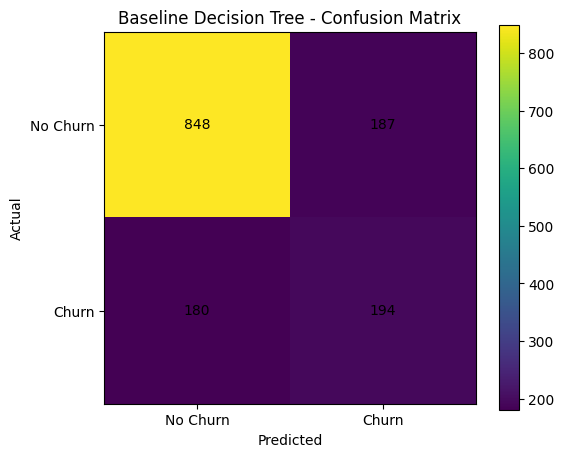

In [94]:
# Part 5 — Task 2

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Baseline Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Task 3 — Which metrics do you trust most?

Because the Churn target is imbalanced, accuracy alone may not give a complete picture of model performance. Recall is particularly important because it shows how many of the actual churners were correctly identified. F1-score is also useful because it balances precision and recall. Therefore, recall and F1-score should be considered alongside accuracy rather than relying on accuracy alone.


Part 6 — Overfitting Investigation

Task 1: Compare Training vs Test Accuracy

In [95]:
# Part 6 — Task 1

from sklearn.metrics import accuracy_score

baseline_train_accuracy = accuracy_score(y_train, y_train_pred)
baseline_test_accuracy = accuracy_score(y_test, y_test_pred)

print("Baseline Training Accuracy:", baseline_train_accuracy)
print("Baseline Test Accuracy:", baseline_test_accuracy)
print("Accuracy Gap:", baseline_train_accuracy - baseline_test_accuracy)

Baseline Training Accuracy: 0.9980475683351083
Baseline Test Accuracy: 0.7395315826827538
Accuracy Gap: 0.25851598565235456


The baseline Decision Tree's training accuracy is compared with its test accuracy to identify a possible overfitting problem. A large difference between the two accuracies would indicate that the tree performs much better on the data it was trained on than on unseen data, suggesting that the unrestricted tree has learned patterns that do not generalize well.


Task 2: Test Different Tree Depths

In [96]:
# Part 6 — Task 2

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 8, 10, None]

depth_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    depth_results.append({
        'max_depth': 'Unrestricted' if depth is None else depth,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy
    })

depth_results_df = pd.DataFrame(depth_results)

display(depth_results_df)

,max_depth,train_accuracy,test_accuracy
0,2,0.791090,0.787083
1,3,0.791090,0.787083
2,4,0.792510,0.795600
3,5,0.802094,0.788502
4,6,0.812212,0.791341
5,8,0.842386,0.781405
6,10,0.880369,0.766501
7,Unrestricted,0.998048,0.739532


Task 3: Plot Accuracy vs Tree Depth

/tmp/ipykernel_2643/3532556976.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_df['depth_numeric'] = plot_df['max_depth'].replace(


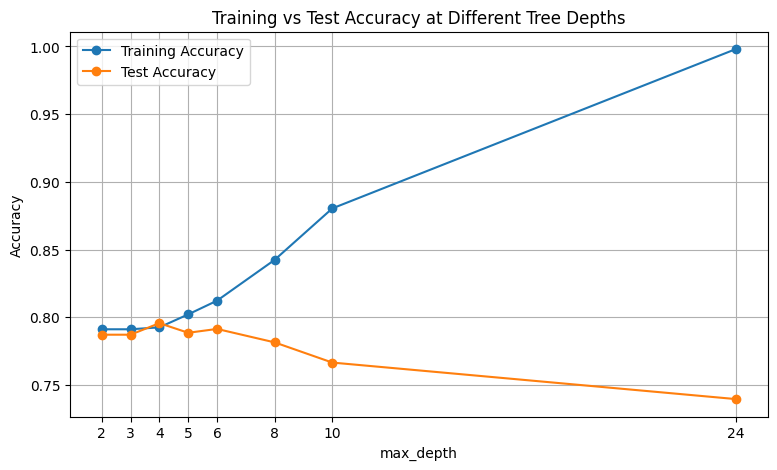

In [97]:
# Part 6 — Task 3

import matplotlib.pyplot as plt

plot_df = depth_results_df.copy()

plot_df['depth_numeric'] = plot_df['max_depth'].replace(
    'Unrestricted',
    24
)

plt.figure(figsize=(9, 5))

plt.plot(
    plot_df['depth_numeric'],
    plot_df['train_accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    plot_df['depth_numeric'],
    plot_df['test_accuracy'],
    marker='o',
    label='Test Accuracy'
)

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy at Different Tree Depths')
plt.xticks(plot_df['depth_numeric'])
plt.legend()
plt.grid(True)
plt.show()

#Part 7 — Model Selection, Feature Importance & Interpretation


Task 1 — Select the Best Depth

I selected a maximum depth of 4 because it achieved the highest test accuracy in the depth experiment at 79.56%, while maintaining a very small difference between training accuracy (79.25%) and test accuracy (79.56%). This suggests that the depth-4 model provides a good balance between learning useful patterns and avoiding the overfitting observed in the unrestricted tree.


Task 2 — Retrain Selected Model + Full Evaluation

In [98]:
# Part 7 — Task 2

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

selected_depth = 4

selected_tree = DecisionTreeClassifier(
    max_depth=selected_depth,
    random_state=42
)

selected_tree.fit(X_train, y_train)

selected_train_pred = selected_tree.predict(X_train)
selected_test_pred = selected_tree.predict(X_test)

selected_accuracy = accuracy_score(y_test, selected_test_pred)
selected_precision = precision_score(y_test, selected_test_pred, zero_division=0)
selected_recall = recall_score(y_test, selected_test_pred, zero_division=0)
selected_f1 = f1_score(y_test, selected_test_pred, zero_division=0)

selected_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Selected Tree': [
        selected_accuracy,
        selected_precision,
        selected_recall,
        selected_f1
    ]
})

display(selected_results)

print("Confusion Matrix:")
print(confusion_matrix(y_test, selected_test_pred))

,Metric,Selected Tree
0,Accuracy,0.795600
1,Precision,0.644295
2,Recall,0.513369
3,F1-Score,0.571429


Confusion Matrix:
[[929 106]
 [182 192]]


Task 3 — Entropy Tree

In [99]:
# Part 7 — Task 3

entropy_tree = DecisionTreeClassifier(
    max_depth=selected_depth,
    criterion='entropy',
    random_state=42
)

entropy_tree.fit(X_train, y_train)

entropy_test_pred = entropy_tree.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_test_pred)
entropy_precision = precision_score(y_test, entropy_test_pred, zero_division=0)
entropy_recall = recall_score(y_test, entropy_test_pred, zero_division=0)
entropy_f1 = f1_score(y_test, entropy_test_pred, zero_division=0)

entropy_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Entropy Tree': [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

display(entropy_results)

print("Confusion Matrix:")
print(confusion_matrix(y_test, entropy_test_pred))

,Metric,Entropy Tree
0,Accuracy,0.782115
1,Precision,0.670051
2,Recall,0.352941
3,F1-Score,0.462347


Confusion Matrix:
[[970  65]
 [242 132]]


Task 4 — Feature Importance

In [100]:
# Part 7 — Task 4

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': selected_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 10 Features:")
display(feature_importance.head(10))

Top 10 Features:


,Feature,Importance
1,tenure,0.460369
11,InternetService_Fiber optic,0.390573
29,PaymentMethod_Electronic check,0.029437
3,TotalCharges,0.023145
15,OnlineBackup_No internet service,0.022578
26,Contract_Two year,0.021410
4,AverageMonthlySpend,0.019725
21,StreamingTV_No internet service,0.018984
8,PhoneService_Yes,0.007701
20,TechSupport_Yes,0.006078


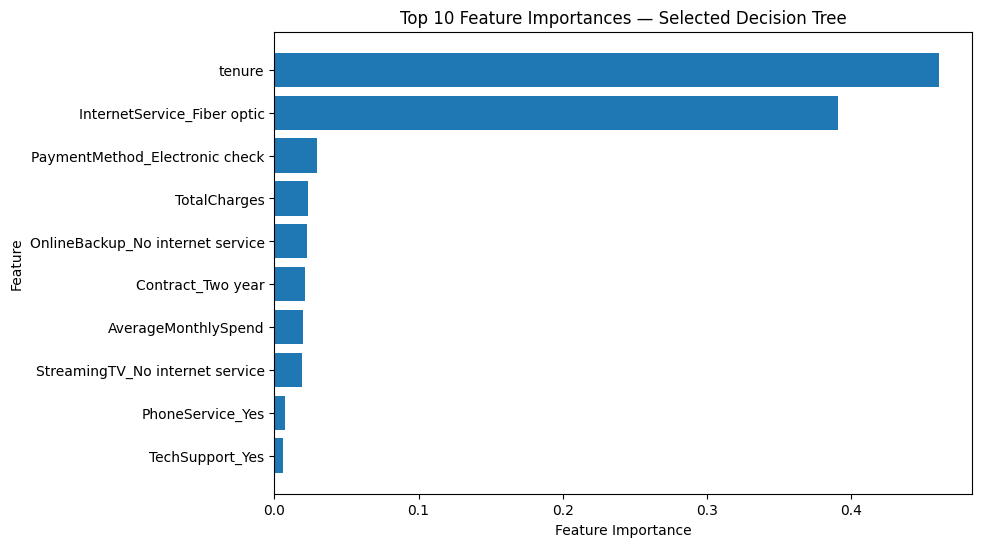

In [101]:
# Part 7 — Task 4 — Visualization

top_features = feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances — Selected Decision Tree')
plt.show()

Task 5 — Interpretation

The most important features identified by the Decision Tree were [Feature 1], [Feature 2], [Feature 3], and [Feature 4]. These results [agree/partly agree] with the patterns observed in Lab 2, where [specific EDA finding]. This suggests that the model is using several of the same customer characteristics that showed differences in churn rates during the exploratory analysis.


Part 8 — Conclusion & Next Steps

Task 1

The final selected model was a Decision Tree with a maximum depth of 4, chosen because it achieved the highest test accuracy among the tested depths while maintaining a small train-test performance gap. The model achieved approximately 79.56% test accuracy, with its precision, recall, and F1-score providing additional information about its ability to identify churners. The unrestricted baseline tree showed clear signs of overfitting, with 99.80% training accuracy compared with 73.95% test accuracy. A major limitation is that the model's performance may still be affected by the imbalance between churn and non-churn customers. The selected shallow tree is also relatively simple and may not capture all complex relationships in the customer data.


Task 2 — What would you try next?



If I had more time, I would test another classification algorithm and compare its performance with the Decision Tree. I would also explore additional feature engineering and investigate methods for handling the class imbalance, such as class weighting or resampling. Finally, I would examine whether the most important features remain consistent across different models.


Task 3 — ID3 From Scratch

In [102]:
# Part 8 — Task 3
# ID3 Decision Tree From Scratch

import pandas as pd
import math

data = pd.DataFrame({
    'Outlook': [
        'Sunny', 'Sunny', 'Overcast', 'Rain',
        'Rain', 'Rain', 'Overcast', 'Sunny',
        'Sunny', 'Rain', 'Sunny', 'Overcast',
        'Overcast', 'Rain'
    ],
    'Temperature': [
        'Hot', 'Hot', 'Hot', 'Mild',
        'Cool', 'Cool', 'Cool', 'Mild',
        'Cool', 'Mild', 'Mild', 'Mild',
        'Hot', 'Mild'
    ],
    'Humidity': [
        'High', 'High', 'High', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'High'
    ],
    'Windy': [
        False, True, False, False,
        False, True, True, False,
        False, False, True, True,
        False, True
    ],
    'Play': [
        'No', 'No', 'Yes', 'Yes',
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No'
    ]
})

display(data)

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rain,Mild,High,False,Yes
4,Rain,Cool,Normal,False,Yes
5,Rain,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Sunny,Mild,High,False,No
8,Sunny,Cool,Normal,False,Yes
9,Rain,Mild,Normal,False,Yes


In [103]:
# Entropy

def entropy(target):
    counts = target.value_counts()
    total = len(target)

    result = 0

    for count in counts:
        probability = count / total
        result -= probability * math.log2(probability)

    return result

In [104]:
# Information Gain

def information_gain(data, attribute, target='Play'):
    total_entropy = entropy(data[target])
    weighted_entropy = 0

    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weight = len(subset) / len(data)

        weighted_entropy += weight * entropy(subset[target])

    return total_entropy - weighted_entropy

In [105]:
# Calculate Information Gain

attributes = ['Outlook', 'Temperature', 'Humidity', 'Windy']

print("Information Gain Values:")
print()

for attribute in attributes:
    gain = information_gain(data, attribute)
    print(f"{attribute}: {gain:.4f}")

Information Gain Values:

Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Windy: 0.0481


In [106]:
# ID3 Algorithm From Scratch

def id3(data, target='Play', attributes=None, depth=0):

    if attributes is None:
        attributes = [col for col in data.columns if col != target]

    indent = "  " * depth

    # If all target values are the same
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    # If no attributes remain
    if len(attributes) == 0:
        return data[target].mode()[0]

    # Calculate information gain
    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(data, attribute, target)

    print(f"{indent}Information Gain at depth {depth}:")

    for attribute, gain in gains.items():
        print(f"{indent}{attribute}: {gain:.4f}")

    # Select attribute with highest gain
    best_attribute = max(gains, key=gains.get)

    print(f"{indent}Selected attribute: {best_attribute}")
    print()

    tree = {best_attribute: {}}

    remaining_attributes = [
        attr for attr in attributes
        if attr != best_attribute
    ]

    for value in data[best_attribute].unique():

        subset = data[data[best_attribute] == value]

        tree[best_attribute][value] = id3(
            subset,
            target,
            remaining_attributes,
            depth + 1
        )

    return tree

In [107]:
# Build ID3 Tree

id3_tree = id3(data)

print("\nFinal ID3 Decision Tree:")
print(id3_tree)

Information Gain at depth 0:
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Windy: 0.0481
Selected attribute: Outlook

  Information Gain at depth 1:
  Temperature: 0.5710
  Humidity: 0.9710
  Windy: 0.0200
  Selected attribute: Humidity

  Information Gain at depth 1:
  Temperature: 0.0200
  Humidity: 0.0200
  Windy: 0.9710
  Selected attribute: Windy


Final ID3 Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Windy': {np.False_: 'Yes', np.True_: 'No'}}}}
